**AN2DL - First Challenge**

team: marcusai

## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ⚙️ **Libraries Import**

In [ ]:
import os
import pathlib

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
from scipy import interpolate

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.feature_selection import mutual_info_classif

np.random.seed(42)
tf.random.set_seed(42)

import warnings
warnings.filterwarnings('ignore')

## ⏳ **Data Loading**

In [ ]:
os.environ["DATASET_NAME"] = "an2dl2526c1.zip"
os.environ["DATASET_URL"] = "1wxH0jDManL9Iveg6dNDCBlUPlBxMy1Ot"

if not os.path.exists(os.environ["DATASET_NAME"]):
    print("Downloading Activity Recognition dataset...")
    !gdown -q ${DATASET_URL} -O ${DATASET_NAME}
    print("Activity Recognition dataset downloaded!")
else:
    print("Activity Recognition dataset already downloaded. Using cached data.")

Activity Recognition dataset already downloaded. Using cached data.


In [ ]:
data_dir = pathlib.Path("data")
data_dir.mkdir(exist_ok=True)
!unzip -oq {os.environ["DATASET_NAME"]} -d {data_dir}

!ls -l data | sed -n '1,8p'

total 190524
-rw-r--r-- 1 root root 131326039 Nov  2 10:34 pirate_pain_test.csv
-rw-r--r-- 1 root root  63736187 Nov  2 10:34 pirate_pain_train.csv
-rw-r--r-- 1 root root      8157 Nov  2 10:34 pirate_pain_train_labels.csv
-rw-r--r-- 1 root root     17536 Nov  2 10:34 sample_submission.csv


In [ ]:
X_train = pd.read_csv("data/pirate_pain_train.csv")
y_train = pd.read_csv("data/pirate_pain_train_labels.csv")
X_test  = pd.read_csv("data/pirate_pain_test.csv")
print(X_train.shape, y_train.shape, X_test.shape)

(105760, 40) (661, 2) (211840, 40)


## 🔎 **Exploration and Data Analysis and Data Engineering**

In [ ]:
non_feature_cols = ['sample_index', 'time']
feature_cols = [c for c in X_train.columns if c not in non_feature_cols]

joint_cols = [c for c in feature_cols if c.startswith("joint_")]
print(len(joint_cols))

joint_cols = [c for c in feature_cols if c.startswith("joint_")]
other_cols = [c for c in feature_cols if c not in joint_cols]

31


In [ ]:
categorical_cols = ['n_legs', 'n_hands', 'n_eyes']

# Apply Label Encoding to categorical columns
for col in categorical_cols:
  if col in X_train.columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
print("Categorical columns encoded.")

Categorical columns encoded.


In [ ]:
# Encode labels to numerical format
label_col = y_train.columns[1]
y_train_labels = y_train[label_col].values

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_labels).astype(np.int64)

print("Labels encoded.")
print(f"  Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Labels encoded.
  Class mapping: {'high_pain': np.int64(0), 'low_pain': np.int64(1), 'no_pain': np.int64(2)}


In [ ]:
y_train_categorical = to_categorical(y_train_encoded, num_classes=len(label_encoder.classes_))
n_classes = len(label_encoder.classes_)

In [ ]:
def prepare_pading(df, feature_cols, label_col=None, target_length=180):
  seqs, labels, ids, lens = [], [], [], []

  for sid, g in df.sort_values(['sample_index','time']).groupby('sample_index'):

    a = g[feature_cols].apply(pd.to_numeric, errors='coerce').ffill().bfill().fillna(0).to_numpy(np.float32)

    if a.size == 0: continue
    L = min(len(a), target_length); lens.append(L)

    if len(a) < target_length:
      pad = np.zeros((target_length, a.shape[1]), a.dtype); pad[:len(a)] = a; a = pad

    elif len(a) > target_length:
      a = a[:target_length]
    seqs.append(a); ids.append(sid)

    if label_col: labels.append(g[label_col].iat[0])

  X, lens = np.array(seqs), np.array(lens)
  return (X, np.array(labels), ids, lens) if label_col else (X, ids, lens)

y_train_encoded_df = pd.DataFrame({
    'sample_index': y_train['sample_index'],
    'encoded_label': y_train_encoded
})

X_train_with_encoded_labels = pd.merge(X_train, y_train_encoded_df, on='sample_index', how='left')

feature_cols = [c for c in X_train_with_encoded_labels.columns
                if c not in ['sample_index','time','encoded_label']]

X_full, y_full, train_sample_ids, train_seq_lengths = prepare_pading(X_train_with_encoded_labels, feature_cols, 'encoded_label', 180)

In [ ]:
def extract_statistical_features_with_kinematics(sequences, feature_cols):
  def s12(x):
      if x.size == 0:
          return [0.0]*12
      d  = np.diff(x)
      zc = np.sum(np.diff(np.sign(x - x.mean())) != 0) / max(len(x), 1)
      return [x.mean(), x.std(), x.min(), x.max(), np.median(x),
              np.percentile(x,25), np.percentile(x,75),
              stats.skew(x, bias=False, nan_policy='omit'),
              stats.kurtosis(x, bias=False, nan_policy='omit'),
              np.mean(x**2), np.sum(np.abs(d)), zc]

  j_idx = [i for i,c in enumerate(feature_cols) if c.startswith('joint_')]
  s_idx = [i for i,c in enumerate(feature_cols) if c.startswith('pain_survey_')]

  out = []
  for sample in sequences:
      feats = []
      for j in j_idx:
          x = sample[:, j]
          # v = np.diff(x)
          # a = np.diff(v)
          # feats += s12(x) + s12(v) + s12(a)
          feats += s12(x)
      for j in s_idx:
          y = sample[:, j]
          feats += [y.mean(), y.std()]
      out.append(feats)
  return np.asarray(out, dtype=np.float32)

In [ ]:
X_full_statistical = extract_statistical_features_with_kinematics(X_full, feature_cols)
n_statistical_features = X_full_statistical.shape[1]
print(f"Statistical features shape: {X_full_statistical.shape}")

Statistical features shape: (661, 380)


## 🛠️ **Model Building**

In [ ]:
class AttentionLayer(layers.Layer):
    """Custom attention layer for time series"""
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        e = tf.keras.backend.squeeze(e, axis=-1)
        alpha = tf.keras.backend.softmax(e)
        alpha = tf.keras.backend.expand_dims(alpha, axis=-1)
        context = inputs * alpha
        context = tf.keras.backend.sum(context, axis=1)
        return context

print("AttentionLayer defined successfully!")

AttentionLayer defined successfully!


In [ ]:
n_samples_full, n_timesteps, n_features = X_full.shape

In [ ]:
def build_hybrid_model(sequence_input_shape, stat_input_shape, n_classes, seed=42):
    """Build hybrid model with sequence and statistical branches"""
    tf.random.set_seed(seed)
    np.random.seed(seed)

    sequence_input = layers.Input(shape=sequence_input_shape, name='sequence_input')
    x = layers.GaussianNoise(0.01)(sequence_input)

    # CNN blocks
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # BiLSTM + Attention
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
    x = layers.BatchNormalization()(x)
    sequence_features = AttentionLayer()(x)

    # STATISTICAL BRANCH
    stat_input = layers.Input(shape=stat_input_shape, name='statistical_input')
    s = layers.Dense(256, activation='relu')(stat_input)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(0.4)(s)
    s = layers.Dense(128, activation='relu')(s)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(0.3)(s)

    # COMBINE === (no changes)
    combined = layers.Concatenate()([sequence_features, s])

    # CLASSIFICATION
    c = layers.Dense(256, activation='relu')(combined)
    c = layers.Dropout(0.5)(c)
    c = layers.Dense(128, activation='relu')(c)
    c = layers.Dropout(0.4)(c)
    outputs = layers.Dense(n_classes, activation='softmax')(c)

    model = models.Model(inputs=[sequence_input, stat_input], outputs=outputs, name='Hybrid_CNN_BiLSTM_Statistical')
    return model

# Test build
test_model = build_hybrid_model((n_timesteps, n_features), (n_statistical_features,), n_classes)
print(f"Hybrid model parameters: {test_model.count_params():,}")
del test_model


Hybrid model parameters: 768,560


## **K-Shuffle-Split Cross Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold
import time

# K-Fold configuration
N_FOLDS = 5
EPOCHS = 100
BATCH_SIZE = 32
RANDOM_SEED = 42

# Initialize K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Storage for models and results
fold_models = []
fold_histories = []
fold_scalers = []
fold_metrics = {
    'train_acc': [],
    'val_acc': [],
    'val_loss': [],
    'val_f1_macro': [],
    'val_f1_weighted': []
}

print("="*60)
print("K-FOLD CROSS-VALIDATION SETUP")
print("="*60)
print(f"Number of folds: {N_FOLDS}")
print(f"Total samples: {len(X_full)}")
print(f"Samples per fold (approx): {len(X_full) // N_FOLDS}")
print(f"Epochs per fold: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Input shape: ({n_timesteps}, {n_features})")
print(f"Number of classes: {n_classes}")
print("="*60 + "\n")


K-FOLD CROSS-VALIDATION SETUP
Number of folds: 5
Total samples: 661
Samples per fold (approx): 132
Epochs per fold: 100
Batch size: 32
Input shape: (180, 38)
Number of classes: 3



In [ ]:
# K-Fold Training with Hybrid Model
import time

fold_models = []
fold_histories = []
fold_scalers_sequence = []
fold_scalers_statistical = []
fold_metrics = {'train_acc': [], 'val_acc': [], 'val_loss': [], 'val_f1_macro': [], 'val_f1_weighted': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_train_encoded), 1):
    print("\n" + "="*60)
    print(f"FOLD {fold}/{N_FOLDS} - HYBRID MODEL")
    print("="*60)

    fold_start_time = time.time()

    # Split both sequence and statistical data
    X_seq_train, X_seq_val = X_full[train_idx], X_full[val_idx]
    X_stat_train, X_stat_val = X_full_statistical[train_idx], X_full_statistical[val_idx]
    y_train_fold, y_val_fold = y_train_categorical[train_idx], y_train_categorical[val_idx]
    y_train_enc, y_val_enc = y_train_encoded[train_idx], y_train_encoded[val_idx]

    # Normalize sequences
    scaler_seq = StandardScaler()
    X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train.reshape(-1, n_features)).reshape(X_seq_train.shape)
    X_seq_val_scaled = scaler_seq.transform(X_seq_val.reshape(-1, n_features)).reshape(X_seq_val.shape)
    fold_scalers_sequence.append(scaler_seq)

    # Normalize statistical features (separate scaler!)
    scaler_stat = StandardScaler()
    X_stat_train_scaled = scaler_stat.fit_transform(X_stat_train)
    X_stat_val_scaled = scaler_stat.transform(X_stat_val)
    fold_scalers_statistical.append(scaler_stat)

    # Class weights
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    class_weights_dict = dict(enumerate(class_weights))

    # Build and compile
    model_fold = build_hybrid_model((n_timesteps, n_features), (n_statistical_features,), n_classes, seed=RANDOM_SEED+fold)
    model_fold.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    # Callbacks
    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0),
        callbacks.ModelCheckpoint(f'hybrid_model_fold_{fold}.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=0)
    ]

    # Train with DUAL INPUTS
    history_fold = model_fold.fit(
        [X_seq_train_scaled, X_stat_train_scaled], y_train_fold,
        validation_data=([X_seq_val_scaled, X_stat_val_scaled], y_val_fold),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weights_dict, callbacks=cbs, verbose=0
    )

    # Load best
    # After training, when loading the model:
    model_fold = keras.models.load_model(
        f'hybrid_model_fold_{fold}.keras',
        custom_objects={
        'AttentionLayer': AttentionLayer,
        }
    )
    # Evaluate
    val_loss, val_acc = model_fold.evaluate([X_seq_val_scaled, X_stat_val_scaled], y_val_fold, verbose=0)
    y_val_pred_proba = model_fold.predict([X_seq_val_scaled, X_stat_val_scaled], verbose=0)
    y_val_pred = np.argmax(y_val_pred_proba, axis=1)
    y_val_true = np.argmax(y_val_fold, axis=1)

    f1_macro = f1_score(y_val_true, y_val_pred, average='macro')
    f1_weighted = f1_score(y_val_true, y_val_pred, average='weighted')

    # Store
    fold_models.append(model_fold)
    fold_histories.append(history_fold)
    fold_metrics['train_acc'].append(history_fold.history['accuracy'][-1])
    fold_metrics['val_acc'].append(val_acc)
    fold_metrics['val_loss'].append(val_loss)
    fold_metrics['val_f1_macro'].append(f1_macro)
    fold_metrics['val_f1_weighted'].append(f1_weighted)

    print(f"Fold {fold}: Acc={val_acc:.4f}, F1={f1_macro:.4f}, Time={time.time()-fold_start_time:.1f}s")
    for cls in label_encoder.classes_:
        report = classification_report(y_val_true, y_val_pred, target_names=label_encoder.classes_, output_dict=True)
        print(f"  {cls}: F1={report[cls]['f1-score']:.4f}")

print("\n" + "="*60)
print("HYBRID K-FOLD COMPLETE")
print("="*60)



FOLD 1/5 - HYBRID MODEL
Fold 1: Acc=0.9098, F1=0.7648, Time=318.9s
  high_pain: F1=0.5455
  low_pain: F1=0.7778
  no_pain: F1=0.9712

FOLD 2/5 - HYBRID MODEL
Fold 2: Acc=0.9394, F1=0.8541, Time=227.2s
  high_pain: F1=0.7692
  low_pain: F1=0.8125
  no_pain: F1=0.9806

FOLD 3/5 - HYBRID MODEL


Fold 3: Acc=0.9167, F1=0.8459, Time=307.3s
  high_pain: F1=0.7826
  low_pain: F1=0.8000
  no_pain: F1=0.9552

FOLD 4/5 - HYBRID MODEL
Fold 4: Acc=0.9394, F1=0.8642, Time=360.9s
  high_pain: F1=0.7273
  low_pain: F1=0.8947
  no_pain: F1=0.9706

FOLD 5/5 - HYBRID MODEL
Fold 5: Acc=0.9015, F1=0.7756, Time=298.7s
  high_pain: F1=0.6316
  low_pain: F1=0.7429
  no_pain: F1=0.9524

HYBRID K-FOLD COMPLETE


In [ ]:
print("\n" + "="*60)
print("AGGREGATE CROSS-VALIDATION RESULTS")
print("="*60)

print(f"\nValidation Accuracy:")
print(f"  Mean: {np.mean(fold_metrics['val_acc']):.4f} ± {np.std(fold_metrics['val_acc']):.4f}")
print(f"  Range: [{np.min(fold_metrics['val_acc']):.4f}, {np.max(fold_metrics['val_acc']):.4f}]")

print(f"\nValidation F1 (Macro):")
print(f"  Mean: {np.mean(fold_metrics['val_f1_macro']):.4f} ± {np.std(fold_metrics['val_f1_macro']):.4f}")
print(f"  Range: [{np.min(fold_metrics['val_f1_macro']):.4f}, {np.max(fold_metrics['val_f1_macro']):.4f}]")

print(f"\nValidation F1 (Weighted):")
print(f"  Mean: {np.mean(fold_metrics['val_f1_weighted']):.4f} ± {np.std(fold_metrics['val_f1_weighted']):.4f}")

print("\n" + "="*60)


AGGREGATE CROSS-VALIDATION RESULTS

Validation Accuracy:
  Mean: 0.9213 ± 0.0155
  Range: [0.9015, 0.9394]

Validation F1 (Macro):
  Mean: 0.8209 ± 0.0420
  Range: [0.7648, 0.8642]

Validation F1 (Weighted):
  Mean: 0.9197 ± 0.0174



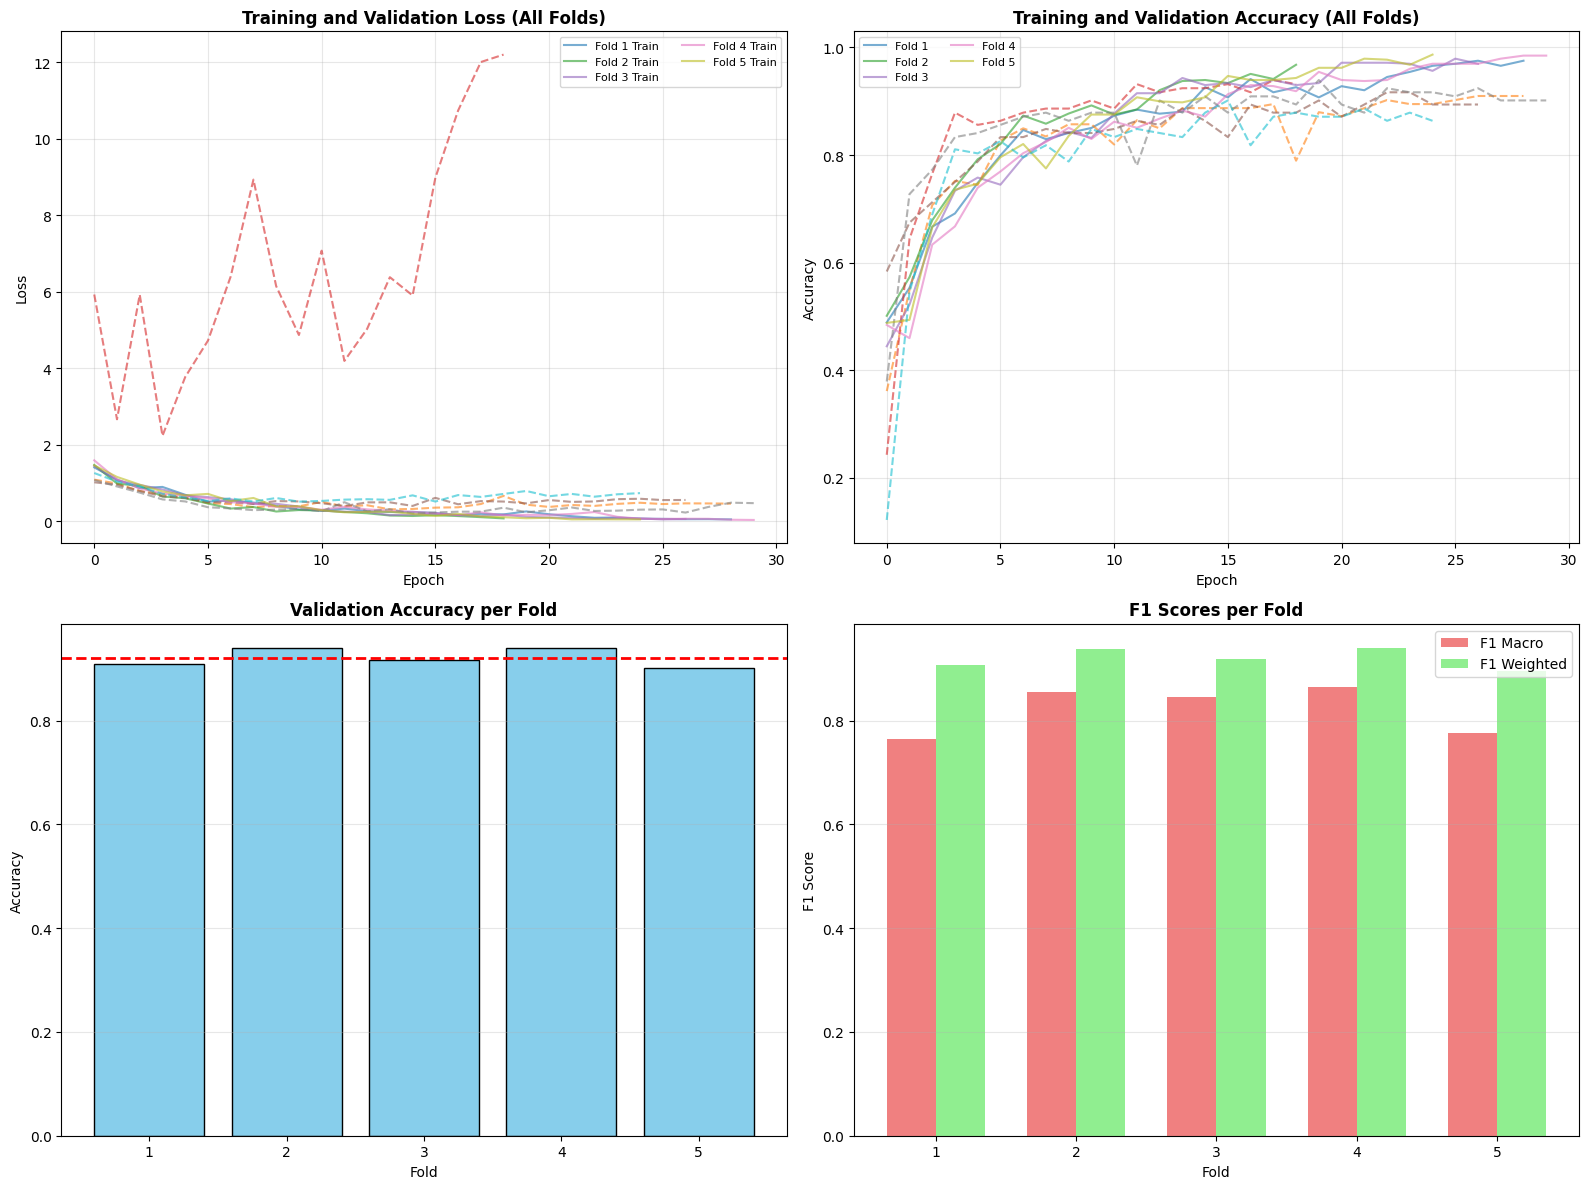

In [ ]:
# Visualize K-Fold Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss curves
for fold, history in enumerate(fold_histories, 1):
    axes[0, 0].plot(history.history['loss'], alpha=0.6, label=f'Fold {fold} Train')
    axes[0, 0].plot(history.history['val_loss'], alpha=0.6, linestyle='--')
axes[0, 0].set_title('Training and Validation Loss (All Folds)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
for fold, history in enumerate(fold_histories, 1):
    axes[0, 1].plot(history.history['accuracy'], alpha=0.6, label=f'Fold {fold}')
    axes[0, 1].plot(history.history['val_accuracy'], alpha=0.6, linestyle='--')
axes[0, 1].set_title('Training and Validation Accuracy (All Folds)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(fontsize=8, ncol=2)
axes[0, 1].grid(True, alpha=0.3)

# Val accuracy per fold
axes[1, 0].bar(range(1, N_FOLDS+1), fold_metrics['val_acc'], color='skyblue', edgecolor='black')
axes[1, 0].axhline(np.mean(fold_metrics['val_acc']), color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Validation Accuracy per Fold', fontweight='bold')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_xticks(range(1, N_FOLDS+1))
axes[1, 0].grid(True, alpha=0.3, axis='y')

# F1 scores
x = np.arange(N_FOLDS)
width = 0.35
axes[1, 1].bar(x - width/2, fold_metrics['val_f1_macro'], width, label='F1 Macro', color='lightcoral')
axes[1, 1].bar(x + width/2, fold_metrics['val_f1_weighted'], width, label='F1 Weighted', color='lightgreen')
axes[1, 1].set_title('F1 Scores per Fold', fontweight='bold')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f'{i+1}' for i in range(N_FOLDS)])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('kfold_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## **Test**

In [ ]:
X_test  = pd.read_csv("data/pirate_pain_test.csv")

In [ ]:
# TEST-TIME AUGMENTATION (TTA)


def add_gaussian_noise_numpy(sequences, noise_level=0.01):
    noise = np.random.normal(0, noise_level, sequences.shape)
    return sequences + noise


def predict_with_tta(model, X_seq, X_stat, n_tta=5, noise_levels=[0.0, 0.005, 0.01]):
    all_predictions = []

    # Original prediction (no noise)
    pred = model.predict([X_seq, X_stat], verbose=0)
    all_predictions.append(pred)

    # Predictions with different noise levels
    for noise_level in noise_levels:
        if noise_level == 0.0:
            continue  # Already did this above

        for _ in range(n_tta):
            # Add noise to sequences only (not statistical features)
            X_seq_noisy = add_gaussian_noise_numpy(X_seq, noise_level)

            # Predict
            pred = model.predict([X_seq_noisy, X_stat], verbose=0)
            all_predictions.append(pred)

    # Average all predictions
    final_pred = np.mean(all_predictions, axis=0)

    return final_pred


print("✅ TTA function defined")
print(f"   Will use {1 + len([x for x in [0.005, 0.01] if x > 0]) * 5} = 11 augmentations per sample")

✅ TTA function defined
   Will use 11 = 11 augmentations per sample


In [ ]:
# Prepare test data
X_test, test_sample_ids, test_seq_lengths = prepare_pading(X_test, feature_cols, label_col=None, target_length=180)

# Extract statistical features from test
print("Extracting statistical features from test set...")
X_test_statistical = extract_statistical_features_with_kinematics(X_test, feature_cols)

print("="*60)
print("HYBRID ENSEMBLE TEST PREDICTION")
print("="*60)
print(f"Test sequence: {X_test.shape}")
print(f"Test statistical: {X_test_statistical.shape}")

# Ensemble with dual inputs
ensemble_proba = np.zeros((len(X_test), n_classes))

for fold, (model, scaler_seq, scaler_stat) in enumerate(zip(fold_models, fold_scalers_sequence, fold_scalers_statistical), 1):
    X_test_seq_scaled = scaler_seq.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)
    X_test_stat_scaled = scaler_stat.transform(X_test_statistical)
    pred = model.predict([X_test_seq_scaled, X_test_stat_scaled], batch_size=32, verbose=0)
    ensemble_proba += pred
    print(f"  Fold {fold}: ✓")

ensemble_proba /= N_FOLDS
ensemble_pred = np.argmax(ensemble_proba, axis=1)
ensemble_labels = label_encoder.inverse_transform(ensemble_pred)


print(f"\nPredicted distribution:")
for label, count in zip(*np.unique(ensemble_labels, return_counts=True)):
    print(f"  {label}: {count} ({count/len(ensemble_labels)*100:.1f}%)")

confidence = np.max(ensemble_proba, axis=1)
print(f"\nConfidence: {np.mean(confidence):.4f} ± {np.std(confidence):.4f}")



=== prepare_sequences_with_padding DEBUG ===
Input df shape: (211840, 40)
Number of unique samples: 1324
Target sequence length: 180

Actual sequence lengths in data:
time
160    1324
Name: count, dtype: int64

Processing results:
  - Sequences with exact length (180): 0
  - Sequences padded: 1324
  - Sequences truncated: 0
  - Total sequences: 1324

Extracting statistical features from test set...
HYBRID ENSEMBLE TEST PREDICTION
Test sequence: (1324, 180, 38)
Test statistical: (1324, 380)
  Fold 1: ✓
  Fold 2: ✓
  Fold 3: ✓
  Fold 4: ✓
  Fold 5: ✓

Predicted distribution:
  high_pain: 89 (6.7%)
  low_pain: 204 (15.4%)
  no_pain: 1031 (77.9%)

Confidence: 0.9129 ± 0.1330


In [ ]:
submission = pd.DataFrame({'sample_index': test_sample_ids, 'label': ensemble_labels})
submission.to_csv('submission_hybrid_ensemble.csv', index=False)
print("\n✅ Saved: submission_hybrid_ensemble.csv")
print(submission.head(10))



✅ Saved: submission_hybrid_ensemble.csv
   sample_index    label
0             0  no_pain
1             1  no_pain
2             2  no_pain
3             3  no_pain
4             4  no_pain
5             5  no_pain
6             6  no_pain
7             7  no_pain
8             8  no_pain
9             9  no_pain


In [1]:
print("\n" + "="*60)
print("HYBRID MODEL SUMMARY")
print("="*60)
print(f"\nValidation Accuracy: {np.mean(fold_metrics['val_acc']):.4f} ± {np.std(fold_metrics['val_acc']):.4f}")
print(f"Validation F1 (Macro): {np.mean(fold_metrics['val_f1_macro']):.4f} ± {np.std(fold_metrics['val_f1_macro']):.4f}")
print(f"\nModel type: Hybrid (Sequence + {n_statistical_features} statistical features)")
print(f"Number of models: {N_FOLDS}")



HYBRID MODEL SUMMARY

Validation Accuracy: 0.9213 ± 0.0155
Validation F1 (Macro): 0.8209 ± 0.0420

Model type: Hybrid (Sequence + 380 statistical features)
Number of models: 5
